ADS-B CONFIGURATION
Sample rate          : 10.0 MSPS
Seed                 : 12345
ADS-B message        : 112 bits
Preamble             : 8.0 us
Payload              : 112.0 us
Signal length        : 120.0 us
Buffer each side     : 24.0 us
Total time           : 168.0 us

Leading buffer       : 240 samples
ADS-B signal         : 1200 samples
Trailing buffer      : 240 samples
Total samples        : 1680
DMA bytes            : 6720
GENERATED ADS-B MESSAGE
DF              : 17
DF bits         : 10001
CRC             : 0xA682C0

112-bit HEX:
8FE7864BC8A386AB732EAFA682C0

112-bit binary:
1000111111100111100001100100101111001000101000111000011010101011011100110010111010101111101001101000001011000000
CRC valid: True
Generated 1680 samples
Phase error : 5.00 deg
Noise std   : 500.0 counts
I min/max   : -1590 / 27630
Q min/max   : -1505 / 27874
PACKED DMA DATA
Number of words : 1680
Bytes           : 6720
dtype           : uint32

First 10 packed words:
[4278582844 4275109967 4217438657 4252827

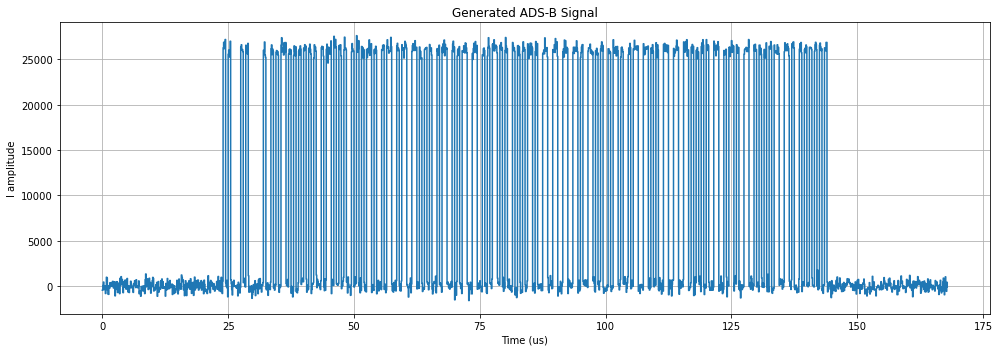

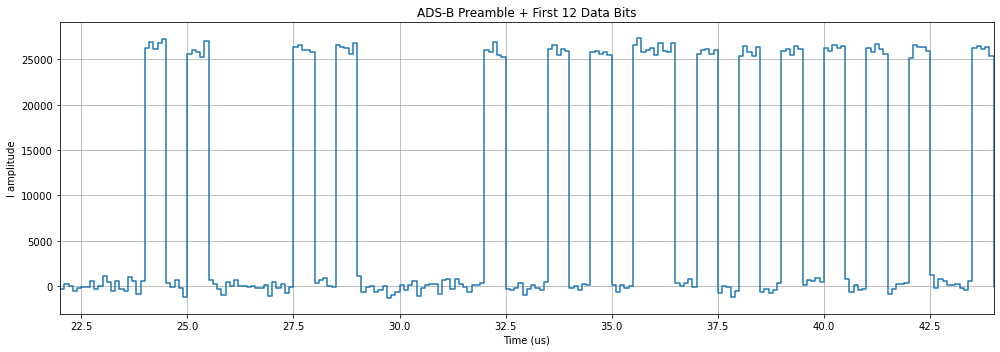

In [1]:
from pynq import Overlay, allocate
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Configuration
# ============================================================

FS = 10_000_000            # 10 MSPS
SEED = 12345               # Repeatable random ADS-B message
AMPLITUDE = 0.8#0.03#0.8            # Fraction of signed int16 full scale

ADS_B_BITS = 112

PREAMBLE_US = 8.0
DATA_US = 112.0

ADS_B_SIGNAL_US = PREAMBLE_US + DATA_US    # 120 us

# 20% of complete ADS-B signal on EACH side
BUFFER_FRACTION = 0.20
BUFFER_US = ADS_B_SIGNAL_US * BUFFER_FRACTION

SAMPLES_PER_US = int(FS / 1e6)

HALF_BIT_SAMPLES = int(0.5 * SAMPLES_PER_US)
BIT_SAMPLES = SAMPLES_PER_US

PREAMBLE_SAMPLES = int(PREAMBLE_US * SAMPLES_PER_US)
DATA_SAMPLES = ADS_B_BITS * BIT_SAMPLES

SIGNAL_SAMPLES = PREAMBLE_SAMPLES + DATA_SAMPLES

BUFFER_SAMPLES = int(BUFFER_US * SAMPLES_PER_US)

TOTAL_SAMPLES = (
    BUFFER_SAMPLES
    + SIGNAL_SAMPLES
    + BUFFER_SAMPLES
)

print("========================================")
print("ADS-B CONFIGURATION")
print("========================================")
print(f"Sample rate          : {FS / 1e6:.1f} MSPS")
print(f"Seed                 : {SEED}")
print(f"ADS-B message        : {ADS_B_BITS} bits")
print(f"Preamble             : {PREAMBLE_US:.1f} us")
print(f"Payload              : {DATA_US:.1f} us")
print(f"Signal length        : {ADS_B_SIGNAL_US:.1f} us")
print(f"Buffer each side     : {BUFFER_US:.1f} us")
print(f"Total time           : {ADS_B_SIGNAL_US + 2*BUFFER_US:.1f} us")
print()
print(f"Leading buffer       : {BUFFER_SAMPLES} samples")
print(f"ADS-B signal         : {SIGNAL_SAMPLES} samples")
print(f"Trailing buffer      : {BUFFER_SAMPLES} samples")
print(f"Total samples        : {TOTAL_SAMPLES}")
print(f"DMA bytes            : {TOTAL_SAMPLES * 4}")

# ============================================================
# Mode-S CRC-24
# ============================================================

def modes_crc24(info_bits):
    """
    Calculate the 24-bit Mode-S CRC remainder.

    info_bits:
        Message bits excluding the final 24 parity bits.

    For a 112-bit DF17 message:
        info_bits = first 88 bits
        CRC       = final 24 bits
    """

    info_bits = np.asarray(info_bits, dtype=np.uint8)

    # Append 24 zeros before polynomial division
    work = np.concatenate([
        info_bits.copy(),
        np.zeros(24, dtype=np.uint8)
    ])

    # Mode-S generator polynomial including x^24 term
    polynomial = 0x1FFF409

    generator = np.array(
        [
            (polynomial >> i) & 1
            for i in range(24, -1, -1)
        ],
        dtype=np.uint8
    )

    # Polynomial long division
    for i in range(len(info_bits)):

        if work[i] == 1:
            work[i:i+25] ^= generator

    return work[-24:]


def bits_to_hex(bit_array):
    value = 0

    for bit in bit_array:
        value = (value << 1) | int(bit)

    num_hex_digits = (len(bit_array) + 3) // 4

    return f"{value:0{num_hex_digits}X}"

    # ============================================================
# Generate DF17 message
# ============================================================

rng = np.random.default_rng(SEED)

bits = np.zeros(ADS_B_BITS, dtype=np.uint8)

# ------------------------------------------------------------
# DF17
#
# Decimal 17 = binary 10001
# ------------------------------------------------------------

bits[0:5] = [
    1,
    0,
    0,
    0,
    1
]

# ------------------------------------------------------------
# Random bits 5 -> 87
#
# Total message:
#
# bits 0:4      DF17        5 bits
# bits 5:87     random     83 bits
# bits 88:111   CRC        24 bits
# ------------------------------------------------------------

bits[5:88] = rng.integers(
    0,
    2,
    size=83,
    dtype=np.uint8
)

# ------------------------------------------------------------
# Calculate correct CRC
# ------------------------------------------------------------

crc_bits = modes_crc24(bits[:88])

bits[88:112] = crc_bits


# ------------------------------------------------------------
# Display message
# ------------------------------------------------------------

message_hex = bits_to_hex(bits)
crc_hex = bits_to_hex(crc_bits)

print("========================================")
print("GENERATED ADS-B MESSAGE")
print("========================================")

print(f"DF              : {int(''.join(str(int(x)) for x in bits[:5]), 2)}")
print(f"DF bits         : {''.join(str(int(x)) for x in bits[:5])}")
print(f"CRC             : 0x{crc_hex}")

print()
print(f"112-bit HEX:")
print(message_hex)

print()
print("112-bit binary:")
print("".join(str(int(x)) for x in bits))

# ============================================================
# Verify CRC
# ============================================================

crc_check = modes_crc24(bits[:88])

crc_valid = np.array_equal(
    crc_check,
    bits[88:112]
)

print(f"CRC valid: {crc_valid}")

if not crc_valid:
    raise RuntimeError("ADS-B CRC generation failed")

    # ============================================================
# Generate ADS-B PPM waveform
# ============================================================

envelope = np.zeros(
    TOTAL_SAMPLES,
    dtype=np.float64
)

# ADS-B waveform begins after leading buffer
signal_start = BUFFER_SAMPLES


# ============================================================
# Preamble
# ============================================================
#
# Mode-S preamble pulses:
#
# 0.0 us
# 1.0 us
# 3.5 us
# 4.5 us
#
# Each pulse is 0.5 us wide.
#
# At 10 MSPS:
#
# 0.5 us = 5 samples
# ============================================================

preamble_pulses_us = [
    0.0,
    1.0,
    3.5,
    4.5
]

for pulse_us in preamble_pulses_us:

    start = (
        signal_start
        + int(pulse_us * SAMPLES_PER_US)
    )

    end = start + HALF_BIT_SAMPLES

    envelope[start:end] = 1.0


# ============================================================
# PPM data
# ============================================================
#
# Each ADS-B bit = 1 us = 10 samples
#
# bit 1:
#
# XXXXX.....
#
# bit 0:
#
# .....XXXXX
#
# ============================================================

data_start = (
    signal_start
    + PREAMBLE_SAMPLES
)

for bit_index, bit in enumerate(bits):

    bit_start = (
        data_start
        + bit_index * BIT_SAMPLES
    )

    if bit == 1:

        # Pulse in first half
        pulse_start = bit_start

    else:

        # Pulse in second half
        pulse_start = (
            bit_start
            + HALF_BIT_SAMPLES
        )

    pulse_end = (
        pulse_start
        + HALF_BIT_SAMPLES
    )

    envelope[pulse_start:pulse_end] = 1.0


print(f"Generated {len(envelope)} samples")

# ============================================================
# Convert envelope to impaired signed int16 IQ
# ============================================================

PEAK_AMPLITUDE = int(
    round(AMPLITUDE * 32767)
)

# ------------------------------------------------------------
# Impairment settings
# ------------------------------------------------------------

PHASE_ERROR_DEG = 5.0    # quadrature error in degrees
NOISE_STD = 500.0        # noise standard deviation in ADC counts

phase_error_rad = np.deg2rad(
    PHASE_ERROR_DEG
)

# Repeatable noise
noise_rng = np.random.default_rng(SEED + 1)

# ------------------------------------------------------------
# Ideal complex IQ
#
# I = envelope * cos(0)
# Q = envelope * sin(90 deg + phase error)
#
# 0 deg error gives ideal I/Q quadrature.
# ------------------------------------------------------------

I_float = (
    envelope
    * PEAK_AMPLITUDE
)

Q_float = (
    envelope
    * PEAK_AMPLITUDE
    * np.sin(
        np.pi / 2 + phase_error_rad
    )
)

# ------------------------------------------------------------
# Add independent Gaussian noise
# ------------------------------------------------------------

I_float += noise_rng.normal(
    0,
    NOISE_STD,
    TOTAL_SAMPLES
)

Q_float += noise_rng.normal(
    0,
    NOISE_STD,
    TOTAL_SAMPLES
)

# ------------------------------------------------------------
# Clip to int16 range
# ------------------------------------------------------------

I_tx = np.clip(
    np.round(I_float),
    -32768,
    32767
).astype(np.int16)

Q_tx = np.clip(
    np.round(Q_float),
    -32768,
    32767
).astype(np.int16)

print(f"Phase error : {PHASE_ERROR_DEG:.2f} deg")
print(f"Noise std   : {NOISE_STD:.1f} counts")
print(f"I min/max   : {I_tx.min()} / {I_tx.max()}")
print(f"Q min/max   : {Q_tx.min()} / {Q_tx.max()}")

# ============================================================
# Pack IQ into uint32
# ============================================================

I_u16 = I_tx.view(np.uint16).astype(np.uint32)

Q_u16 = Q_tx.view(np.uint16).astype(np.uint32)

packed_tx = (
    I_u16
    | (Q_u16 << 16)
).astype(np.uint32)


TLAST_SAMPLES = 256

NUM_FRAMES = int(
    np.ceil(len(packed_tx) / TLAST_SAMPLES)
)

PADDED_SAMPLES = NUM_FRAMES * TLAST_SAMPLES

packed_tx_padded = np.zeros(
    PADDED_SAMPLES,
    dtype=np.uint32
)

packed_tx_padded[:len(packed_tx)] = packed_tx

print("========================================")
print("PACKED DMA DATA")
print("========================================")

print(f"Number of words : {len(packed_tx)}")
print(f"Bytes           : {packed_tx.nbytes}")
print(f"dtype           : {packed_tx.dtype}")

print()
print("First 10 packed words:")
print(packed_tx[:10])

# ============================================================
# Plot generated ADS-B waveform
# ============================================================

t_us = (
    np.arange(TOTAL_SAMPLES)
    / FS
    * 1e6
)

plt.figure(figsize=(14, 5))

plt.step(
    t_us,
    I_tx,
    where="post"
)

plt.xlabel("Time (us)")
plt.ylabel("I amplitude")
plt.title("Generated ADS-B Signal")
plt.grid(True)

plt.tight_layout()
plt.show()

# ============================================================
# Zoom into preamble
# ============================================================

plt.figure(figsize=(14, 5))

plt.step(
    t_us,
    I_tx,
    where="post"
)

plt.xlim(
    BUFFER_US - 2,
    BUFFER_US + PREAMBLE_US + 12
)

plt.xlabel("Time (us)")
plt.ylabel("I amplitude")
plt.title("ADS-B Preamble + First 12 Data Bits")
plt.grid(True)

plt.tight_layout()
plt.show()

Matched-filter DMA:

Magnitude-squared DMA:

DMA frame size : 256 samples
DMA frame bytes: 1024

Starting DMA capture...
Frame 1/7 received
Frame 2/7 received
Frame 3/7 received
Frame 4/7 received
Frame 5/7 received
Frame 6/7 received
Frame 7/7 received

DMA capture complete
Matched samples : 1792
Magnitude samples: 1792

FPGA OUTPUT
Matched min : -431161431
Matched max : 645722481
Magnitude min: 0
Magnitude max: 1491338602

PREAMBLE DETECTION
Peak sample : 319
Peak value  : 645722481

Data start sample : 320
Data end sample   : 1439
Samples required  : 1120

DECODED ADS-B MESSAGE
Decoded binary:
1000111111100111100001100100101111001000101000111000011010101011011100110010111010101111101001101000001011000000

Decoded HEX:
8FE7864BC8A386AB732EAFA682C0

DECODED CRC CHECK
Received CRC   : 0xA682C0
Calculated CRC : 0xA682C0
CRC valid      : True

ORIGINAL vs DECODED
Original HEX : 8FE7864BC8A386AB732EAFA682C0
Decoded HEX  : 8FE7864BC8A386AB732EAFA682C0

Bit errors   : 0/112
MESSAGE MATCH: P

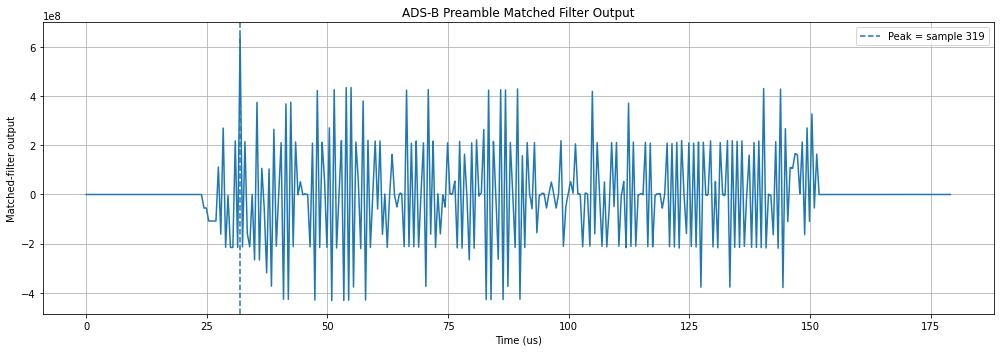

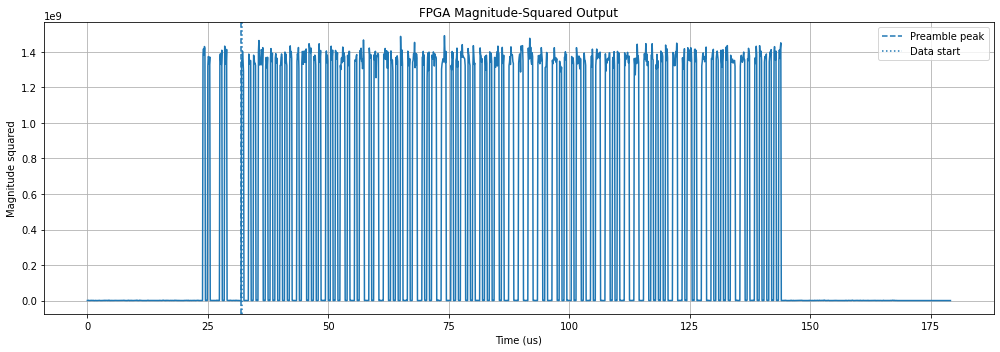

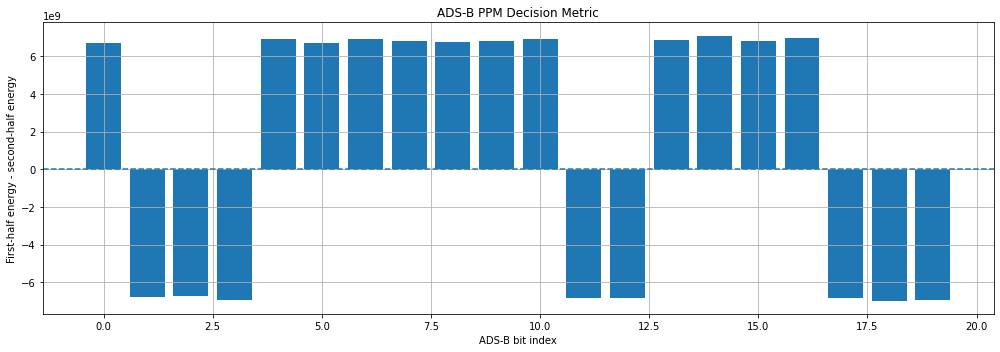

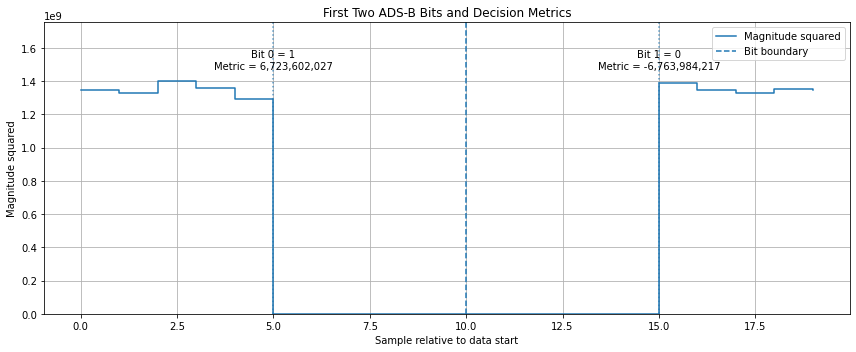


DMA buffers freed


In [2]:
# ============================================================
# Load FPGA overlay
# ============================================================

ol = Overlay("top_design.bit")

# DMA 0:
#   MM2S = ADS-B test waveform into FPGA
#   S2MM = matched-filter output
dma_match = ol.axi_dma_0

# DMA 1:
#   S2MM = magnitude-squared stream
dma_mag = ol.axi_dma_1

print("Matched-filter DMA:")
print(dma_match)

print()
print("Magnitude-squared DMA:")
print(dma_mag)


# ============================================================
# Allocate physically contiguous DMA buffers
# ============================================================

tx_buffer = allocate(
    shape=(TLAST_SAMPLES,),
    dtype=np.uint32
)

matched_rx_buffer = allocate(
    shape=(TLAST_SAMPLES,),
    dtype=np.uint32
)

mag_rx_buffer = allocate(
    shape=(TLAST_SAMPLES,),
    dtype=np.uint32
)

print()
print(f"DMA frame size : {TLAST_SAMPLES} samples")
print(f"DMA frame bytes: {TLAST_SAMPLES * 4}")


# ============================================================
# DMA transfer
#
# Both receive DMAs are armed before transmitting each frame.
#
# dma_match:
#     input waveform -> FPGA
#     matched-filter output <- FPGA
#
# dma_mag:
#     magnitude-squared output <- FPGA
# ============================================================

matched_rx_frames = []
mag_rx_frames = []

print()
print("Starting DMA capture...")

for frame in range(NUM_FRAMES):

    start = frame * TLAST_SAMPLES
    end   = start + TLAST_SAMPLES

    # --------------------------------------------------------
    # Load next transmitted frame
    # --------------------------------------------------------

    tx_buffer[:] = packed_tx_padded[start:end]

    matched_rx_buffer[:] = 0
    mag_rx_buffer[:] = 0

    # --------------------------------------------------------
    # ARM BOTH RECEIVERS FIRST
    # --------------------------------------------------------

    dma_match.recvchannel.transfer(matched_rx_buffer)
    dma_mag.recvchannel.transfer(mag_rx_buffer)

    # --------------------------------------------------------
    # Then start transmitted waveform
    # --------------------------------------------------------

    dma_match.sendchannel.transfer(tx_buffer)

    # Wait for all three transfers
    dma_match.sendchannel.wait()

    dma_match.recvchannel.wait()
    dma_mag.recvchannel.wait()

    # --------------------------------------------------------
    # Save received data before buffers are reused
    # --------------------------------------------------------

    matched_rx_frames.append(
        np.asarray(
            matched_rx_buffer,
            dtype=np.uint32
        ).copy()
    )

    mag_rx_frames.append(
        np.asarray(
            mag_rx_buffer,
            dtype=np.uint32
        ).copy()
    )

    print(
        f"Frame {frame + 1}/{NUM_FRAMES} received"
    )


# ============================================================
# Concatenate received frames
# ============================================================

packed_matched_rx = np.concatenate(
    matched_rx_frames
)

packed_mag_rx = np.concatenate(
    mag_rx_frames
)

print()
print("DMA capture complete")

print(
    f"Matched samples : {len(packed_matched_rx)}"
)

print(
    f"Magnitude samples: {len(packed_mag_rx)}"
)


# ============================================================
# Interpret FPGA outputs
# ============================================================

# Matched-filter output is signed 32-bit
matched = packed_matched_rx.view(np.int32)

# Magnitude squared is positive.
#
# Convert to uint64 for subsequent sums so adding several
# uint32 magnitude values cannot overflow.
mag_squared = packed_mag_rx.astype(np.uint64)


print()
print("========================================")
print("FPGA OUTPUT")
print("========================================")

print(f"Matched min : {matched.min()}")
print(f"Matched max : {matched.max()}")

print(f"Magnitude min: {mag_squared.min()}")
print(f"Magnitude max: {mag_squared.max()}")


# ============================================================
# Find ADS-B preamble using matched filter
# ============================================================

peak_index = int(
    np.argmax(matched)
)

peak_value = matched[peak_index]

print()
print("========================================")
print("PREAMBLE DETECTION")
print("========================================")

print(f"Peak sample : {peak_index}")
print(f"Peak value  : {peak_value}")


# ============================================================
# Locate ADS-B data in magnitude-squared stream
# ============================================================
#
# The matched-filter correlation peak occurs at the LAST
# sample of the 8 us preamble.
#
# Therefore:
#
#     first data sample = peak_index + 1
#
# For your generated signal:
#
#     leading buffer = 240 samples
#     preamble       =  80 samples
#
#     expected peak = 319
#     data starts   = 320
#
# ============================================================

data_start_index = peak_index + 1

data_end_index = (
    data_start_index
    + ADS_B_BITS * BIT_SAMPLES
)

print()
print(f"Data start sample : {data_start_index}")
print(f"Data end sample   : {data_end_index - 1}")
print(f"Samples required  : {ADS_B_BITS * BIT_SAMPLES}")


# ============================================================
# Make sure enough magnitude-squared data was captured
# ============================================================

if data_end_index > len(mag_squared):

    raise RuntimeError(
        "Not enough magnitude-squared samples captured "
        "to decode the complete 112-bit ADS-B message."
    )


# ============================================================
# Extract ADS-B data portion
# ============================================================

mag_data = mag_squared[
    data_start_index:data_end_index
]


# ============================================================
# Reshape into one row per ADS-B bit
#
# 10 MSPS:
#
#     1 ADS-B bit = 10 samples
#
# Each row:
#
#     samples 0:4 = first  0.5 us
#     samples 5:9 = second 0.5 us
#
# ADS-B PPM:
#
#     bit 1 -> energy in FIRST half
#     bit 0 -> energy in SECOND half
# ============================================================

bit_windows = mag_data.reshape(
    ADS_B_BITS,
    BIT_SAMPLES
)


# ============================================================
# Calculate energy in each half-bit
# ============================================================

first_half_energy = np.sum(
    bit_windows[:, :HALF_BIT_SAMPLES],
    axis=1,
    dtype=np.uint64
)

second_half_energy = np.sum(
    bit_windows[:, HALF_BIT_SAMPLES:],
    axis=1,
    dtype=np.uint64
)


# ============================================================
# Decode bits
#
# First-half energy > second-half energy -> 1
# Otherwise                               -> 0
# ============================================================

decoded_bits = (
    first_half_energy
    > second_half_energy
).astype(np.uint8)


# ============================================================
# Decision metric
#
# Positive -> bit 1
# Negative -> bit 0
# ============================================================

decision_metric = (
    first_half_energy.astype(np.int64)
    - second_half_energy.astype(np.int64)
)


# ============================================================
# Check for ambiguous / tied bits
# ============================================================

tie_indices = np.where(
    first_half_energy == second_half_energy
)[0]

if len(tie_indices) > 0:

    print()
    print(
        "WARNING: equal first/second-half energy "
        f"for bits: {tie_indices.tolist()}"
    )


# ============================================================
# Display decoded message
# ============================================================

decoded_hex = bits_to_hex(
    decoded_bits
)

print()
print("========================================")
print("DECODED ADS-B MESSAGE")
print("========================================")

print("Decoded binary:")

print(
    "".join(
        str(int(x))
        for x in decoded_bits
    )
)

print()
print(f"Decoded HEX:")
print(decoded_hex)


# ============================================================
# CRC check on DECODED message
# ============================================================
#
# First 88 bits:
#     ADS-B message information
#
# Final 24 bits:
#     received CRC
#
# Recalculate CRC from decoded first 88 bits and compare.
# ============================================================

decoded_crc_received = decoded_bits[88:112]

decoded_crc_calculated = modes_crc24(
    decoded_bits[:88]
)

decoded_crc_valid = np.array_equal(
    decoded_crc_calculated,
    decoded_crc_received
)


print()
print("========================================")
print("DECODED CRC CHECK")
print("========================================")

print(
    "Received CRC   : 0x"
    + bits_to_hex(decoded_crc_received)
)

print(
    "Calculated CRC : 0x"
    + bits_to_hex(decoded_crc_calculated)
)

print(
    f"CRC valid      : {decoded_crc_valid}"
)


# ============================================================
# Compare decoded message against ORIGINAL generated message
# ============================================================

bit_error_mask = (
    decoded_bits != bits
)

bit_error_indices = np.where(
    bit_error_mask
)[0]

num_bit_errors = len(
    bit_error_indices
)


print()
print("========================================")
print("ORIGINAL vs DECODED")
print("========================================")

print(f"Original HEX : {message_hex}")
print(f"Decoded HEX  : {decoded_hex}")

print()
print(
    f"Bit errors   : "
    f"{num_bit_errors}/{ADS_B_BITS}"
)

if num_bit_errors == 0:

    print("MESSAGE MATCH: PASS")

else:

    print("MESSAGE MATCH: FAIL")

    print(
        "Incorrect bit indices:",
        bit_error_indices.tolist()
    )

    print()
    print("Bit differences:")

    for index in bit_error_indices:

        print(
            f"  bit {index:3d}: "
            f"TX={bits[index]} "
            f"RX={decoded_bits[index]} "
            f"metric={decision_metric[index]}"
        )


# ============================================================
# Overall result
# ============================================================

print()
print("========================================")
print("FINAL RESULT")
print("========================================")

if (
    decoded_crc_valid
    and num_bit_errors == 0
):

    print("PASS")

    print(
        "Preamble detected, "
        "all 112 bits recovered correctly, "
        "and CRC passed."
    )

elif decoded_crc_valid:

    print(
        "CRC PASS, but decoded message differs "
        "from generated input."
    )

else:

    print("FAIL")

    print(
        "Decoded message failed CRC."
    )


# ============================================================
# Plot matched-filter output
# ============================================================

t_rx_us = (
    np.arange(len(matched))
    / FS
    * 1e6
)

plt.figure(figsize=(14, 5))

plt.plot(
    t_rx_us,
    matched
)

plt.axvline(
    peak_index / FS * 1e6,
    linestyle="--",
    label=f"Peak = sample {peak_index}"
)

plt.xlabel("Time (us)")
plt.ylabel("Matched-filter output")
plt.title("ADS-B Preamble Matched Filter Output")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# Plot magnitude squared
# ============================================================

t_mag_us = (
    np.arange(len(mag_squared))
    / FS
    * 1e6
)

plt.figure(figsize=(14, 5))

plt.plot(
    t_mag_us,
    mag_squared
)

plt.axvline(
    peak_index / FS * 1e6,
    linestyle="--",
    label="Preamble peak"
)

plt.axvline(
    data_start_index / FS * 1e6,
    linestyle=":",
    label="Data start"
)

plt.xlabel("Time (us)")
plt.ylabel("Magnitude squared")
plt.title("FPGA Magnitude-Squared Output")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# Plot first 20 decoded bit decisions
# ============================================================

NUM_BITS_TO_PLOT = 20

plt.figure(figsize=(14, 5))

plt.bar(
    np.arange(NUM_BITS_TO_PLOT),
    decision_metric[:NUM_BITS_TO_PLOT]
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("ADS-B bit index")
plt.ylabel("First-half energy - second-half energy")
plt.title("ADS-B PPM Decision Metric")
plt.grid(True)

plt.tight_layout()
plt.show()

# ============================================================
# Plot first two ADS-B bits with decision metrics
# ============================================================

NUM_BITS_TO_SHOW = 2

plot_start = data_start_index
plot_end = (
    data_start_index
    + NUM_BITS_TO_SHOW * BIT_SAMPLES
)

# Relative sample numbers from the start of the ADS-B data
sample_axis = np.arange(
    NUM_BITS_TO_SHOW * BIT_SAMPLES
)

plt.figure(figsize=(12, 5))

plt.step(
    sample_axis,
    mag_squared[plot_start:plot_end],
    where="post",
    label="Magnitude squared"
)

# ------------------------------------------------------------
# Mark boundary between the two bits
# ------------------------------------------------------------

plt.axvline(
    BIT_SAMPLES,
    linestyle="--",
    label="Bit boundary"
)

# ------------------------------------------------------------
# Mark half-bit boundaries
# ------------------------------------------------------------

plt.axvline(
    HALF_BIT_SAMPLES,
    linestyle=":",
    alpha=0.7
)

plt.axvline(
    BIT_SAMPLES + HALF_BIT_SAMPLES,
    linestyle=":",
    alpha=0.7
)

# ------------------------------------------------------------
# Add decision metric and decoded value above each bit
# ------------------------------------------------------------

y_max = np.max(
    mag_squared[plot_start:plot_end]
)

for bit_idx in range(NUM_BITS_TO_SHOW):

    bit_centre = (
        bit_idx * BIT_SAMPLES
        + BIT_SAMPLES / 2
    )

    plt.text(
        bit_centre,
        y_max * 1.05,
        (
            f"Bit {bit_idx} = {decoded_bits[bit_idx]}\n"
            f"Metric = {decision_metric[bit_idx]:,}"
        ),
        horizontalalignment="center"
    )

plt.xlabel("Sample relative to data start")
plt.ylabel("Magnitude squared")

plt.title(
    "First Two ADS-B Bits and Decision Metrics"
)

plt.grid(True)
plt.legend()

# Give annotations some room above waveform
plt.ylim(
    0,
    y_max * 1.25
)

plt.tight_layout()
plt.show()


# ============================================================
# Free DMA buffers
# ============================================================

tx_buffer.freebuffer()
matched_rx_buffer.freebuffer()
mag_rx_buffer.freebuffer()

print()
print("DMA buffers freed")